In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --------------------------------------------------
# Load NAV History
# --------------------------------------------------

nav = pd.read_csv(
    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\processed\\nav_history_clean.csv"
)

# --------------------------------------------------
# Load Fund Master
# --------------------------------------------------

fund = pd.read_csv(
    "C:\\Users\\tekam\\Downloads\\Data Science\\Data_Analyst_Portfolio_Project\\data\\raw\\01_fund_master.csv"
)

# --------------------------------------------------
# Date Conversion
# --------------------------------------------------

nav["date"] = pd.to_datetime(nav["date"])

# --------------------------------------------------
# Merge Scheme Name
# --------------------------------------------------

nav = nav.merge(

    fund[["amfi_code","scheme_name"]],

    on="amfi_code",

    how="left"

)

# --------------------------------------------------
# Sort Data
# --------------------------------------------------

nav = nav.sort_values(

    ["amfi_code","date"]

).reset_index(drop=True)

print("="*60)
print("NAV Dataset Loaded Successfully")
print("="*60)
print("Rows :", len(nav))
print("Schemes :", nav["scheme_name"].nunique())

display(nav.head())

NAV Dataset Loaded Successfully
Rows : 46000
Schemes : 40


,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [13]:
# --------------------------------------------------
# Daily Returns
# --------------------------------------------------

nav["daily_return"] = (

    nav.groupby("amfi_code")["nav"]

       .pct_change()

)

nav = nav.dropna().reset_index(drop=True)

print("="*60)
print("Daily Returns Calculated")
print("="*60)

display(nav.head())

Daily Returns Calculated


,amfi_code,date,nav,scheme_name,daily_return
0,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,-0.010306
1,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,0.012865
2,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,-0.011377
3,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,-0.001210
4,100016,2022-01-10,510.7136,HDFC Top 100 Fund - Regular Plan - Growth,-0.008639


In [14]:
# ==========================================================
# Historical VaR (95%) & CVaR (95%)
# ==========================================================

risk_results = []

for scheme, df in nav.groupby("scheme_name"):

    returns = df["daily_return"].dropna()

    # Skip funds with very few observations
    if len(returns) < 30:
        continue

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Historical CVaR (Expected Shortfall)
    cvar95 = returns[returns <= var95].mean()

    risk_results.append({

        "Scheme Name": scheme,
        "VaR_95": round(var95, 6),
        "CVaR_95": round(cvar95, 6),
        "Observations": len(returns)

    })

risk_df = pd.DataFrame(risk_results)

print("="*60)
print("Historical VaR & CVaR Calculated Successfully")
print("="*60)

display(risk_df.head())

Historical VaR & CVaR Calculated Successfully


,Scheme Name,VaR_95,CVaR_95,Observations
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439,1149
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422,1149
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,1149
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487,1149
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328,1149


In [7]:
results = []

for scheme, df in nav.groupby("scheme_name"):

    returns = df["daily_return"]

    var95 = np.percentile(

        returns,

        5

    )

    cvar95 = returns[

        returns <= var95

    ].mean()

    results.append({

        "Scheme Name": scheme,

        "VaR_95": round(var95,6),

        "CVaR_95": round(cvar95,6)

    })

risk_df = pd.DataFrame(results)

risk_df.head()

,Scheme Name,VaR_95,CVaR_95
0,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
1,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,Axis Bluechip Fund - Direct - Growth,-0.014226,-0.017487
4,Axis Bluechip Fund - Regular - Growth,-0.013750,-0.017328


In [15]:
# ==========================================================
# Rank Funds by VaR
# ==========================================================

risk_df = risk_df.sort_values(

    "VaR_95"

).reset_index(drop=True)

risk_df["Risk Rank"] = range(

    1,

    len(risk_df)+1

)

display(risk_df)

,Scheme Name,VaR_95,CVaR_95,Observations,Risk Rank
0,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,1149,1
1,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,1149,2
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,1149,3
3,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,1149,4
4,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,1149,5
5,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036,1149,6
6,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251,1149,7
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456,1149,8
8,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342,1149,9
9,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260,1149,10


In [9]:
# =====================================================
# Calculate Daily Returns
# =====================================================

nav["daily_return"] = (

    nav.groupby("amfi_code")["nav"]

       .pct_change()

)

nav = nav.dropna().reset_index(drop=True)

print("Total Records :", len(nav))

nav.head()

Total Records : 45920


,amfi_code,date,nav,daily_return,scheme_name
0,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-10,510.7136,-0.008639,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-11,513.5542,0.005562,HDFC Top 100 Fund - Regular Plan - Growth


In [16]:
# ==========================================================
# Save CSV
# ==========================================================

os.makedirs(

    "data/processed",

    exist_ok=True

)

risk_df.to_csv(

    "data/processed/var_cvar_report.csv",

    index=False

)

print("✅ var_cvar_report.csv Saved Successfully")

✅ var_cvar_report.csv Saved Successfully


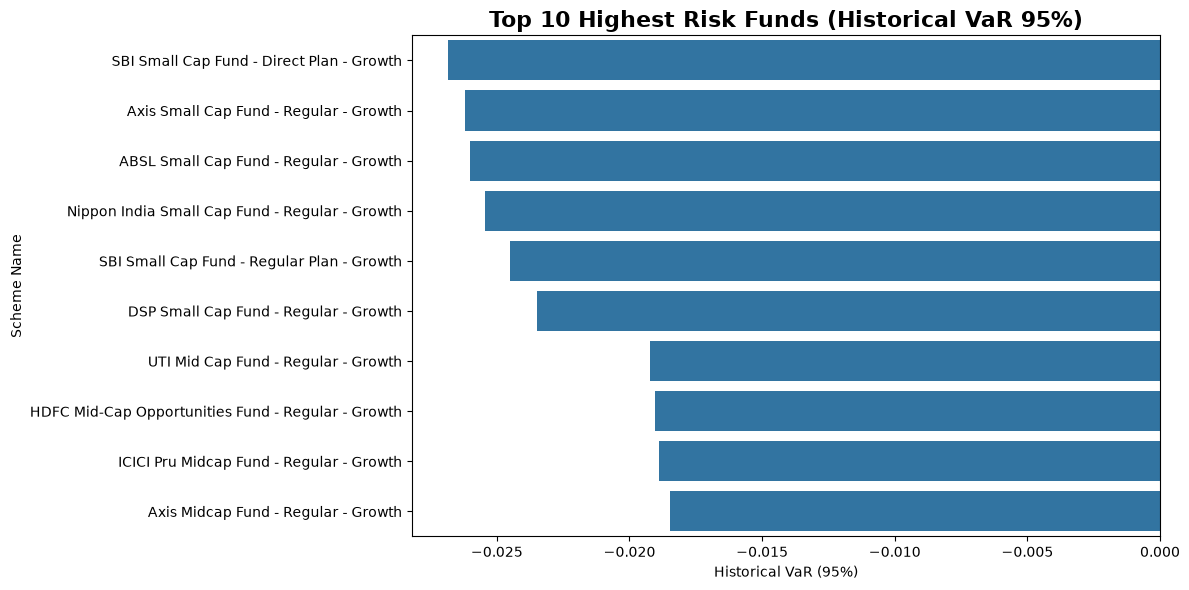

✅ top10_var95.png Saved Successfully


In [17]:
# ==========================================================
# Top 10 Highest Risk Funds (VaR)
# ==========================================================

top10 = risk_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top10,

    x="VaR_95",

    y="Scheme Name"

)

plt.title(

    "Top 10 Highest Risk Funds (Historical VaR 95%)",

    fontsize=16,

    weight="bold"

)

plt.xlabel("Historical VaR (95%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

os.makedirs(

    "dashboard",

    exist_ok=True

)

plt.savefig(

    "dashboard/top10_var95.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ top10_var95.png Saved Successfully")

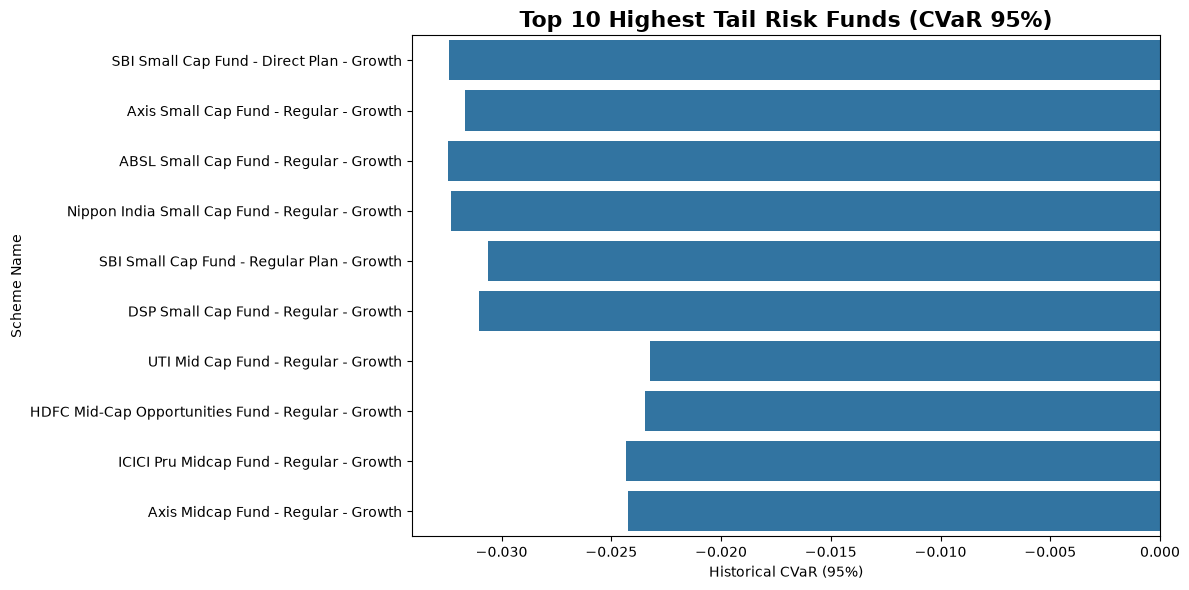

✅ top10_cvar95.png Saved Successfully


In [18]:
# ==========================================================
# Top 10 Highest Tail Risk Funds (CVaR)
# ==========================================================

top10 = risk_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(

    data=top10,

    x="CVaR_95",

    y="Scheme Name"

)

plt.title(

    "Top 10 Highest Tail Risk Funds (CVaR 95%)",

    fontsize=16,

    weight="bold"

)

plt.xlabel("Historical CVaR (95%)")

plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(

    "dashboard/top10_cvar95.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✅ top10_cvar95.png Saved Successfully")

In [19]:
# ==========================================================
# Summary Statistics
# ==========================================================

print("="*60)
print("Historical VaR & CVaR Summary")
print("="*60)

print("Total Funds Analysed :", len(risk_df))

print("\nTop 5 Highest Risk Funds")

display(risk_df.head())

print("\nTop 5 Lowest Risk Funds")

display(risk_df.tail())

Historical VaR & CVaR Summary
Total Funds Analysed : 40

Top 5 Highest Risk Funds


,Scheme Name,VaR_95,CVaR_95,Observations,Risk Rank
0,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384,1149,1
1,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667,1149,2
2,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459,1149,3
3,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304,1149,4
4,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595,1149,5



Top 5 Lowest Risk Funds


,Scheme Name,VaR_95,CVaR_95,Observations,Risk Rank
35,Nippon India Gilt Securities Fund - Regular - ...,-0.003804,-0.004919,1149,36
36,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994,1149,37
37,Kotak Liquid Fund - Regular - Growth,-0.000285,-0.000411,1149,38
38,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422,1149,39
39,ICICI Pru Liquid Fund - Regular - Growth,-0.000222,-0.000373,1149,40
